In [74]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal , Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [75]:
generator_llm = ChatGroq(model='llama-3.1-8b-instant')
evaluator_llm = ChatGroq(model='llama-3.1-8b-instant')
optimizer_llm = ChatGroq(model='llama-3.1-8b-instant')


In [76]:
from pydantic import BaseModel, Field

class TweetEvalution(BaseModel):
    evaluation: Literal['approved','needs_improvement'] = Field(..., description='Final evalution result')
    feedback: str = Field(..., description=' Feedback for the tweet')

In [77]:
structure_evaluator_llm = evaluator_llm.with_structured_output(TweetEvalution)

In [78]:
# state
import operator


class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'rejected']
    feedback: str
    iteration : int
    max_iterations: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [79]:
def generator(state: TweetState) -> TweetState:
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""Write a short, original, and hilarious tweet on the topic: {state['topic']}.
        rules:
        - Do not use question-answer format.
        - max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        - This is version {state['iteration'] + 1}.
        """),
    ]
    
    #  send to llm
    response = generator_llm.invoke(messages).content

    # return response
    return {"tweet": response, 'tweet_history': [response] }

def evaluator(state: TweetState) -> TweetState:
    # prompt
    messages = [
       SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]
    
    # send to llm
    response = structure_evaluator_llm.invoke(messages)
    
    # return response
    return {"evaluation": response.evaluation, "feedback": response.feedback, 'feedback_history': [response.feedback]}

def optimizer(state: TweetState) -> TweetState:
    # prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    
    # send to llm
    response = optimizer_llm.invoke(messages)
    iteration = state['iteration'] + 1
    # return response
    return {"tweet": response.content, 'tweet_history': [response.content]}

In [80]:
def route_evalution(state: TweetState) -> str:
    # TODO: Implement logic to decide next step
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [81]:
graph = StateGraph(TweetState)

graph.add_node("generator", generator)
graph.add_node("evaluator", evaluator)
graph.add_node("optimizer", optimizer)

graph.add_edge(START, "generator")
graph.add_edge("generator", "evaluator")
graph.add_conditional_edges('evaluator', route_evalution, {'approved': END, 'needs_improvement': 'optimizer'})
graph.add_edge("optimizer", "evaluator")

workflow = graph.compile()

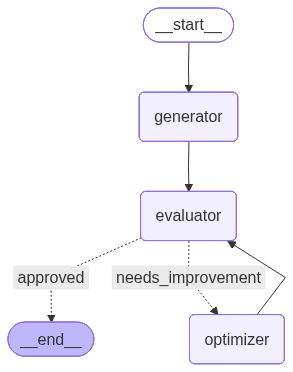

In [82]:
workflow

In [109]:
inital_state = {
    "topic": "watching paint dry and feeling emotional about it",
    "iteration": 1,
    "max_iterations": 5
}

data = workflow.invoke(inital_state)

for key, value in data.items():
    if key == 'iteration' or key == 'tweet_history' or key == 'feedback':
        print(f"{key}: {value}")
        print("-" * 50)


feedback: This tweet gets a thumbs-up for its original and relatable content, with a dash of humor that effectively pokes fun at the struggles of adulthood. The use of the paint's transformation as a metaphor is clever and adds a layer of depth to the joke. However, one potential weakness is that the tweet's punchline is slightly long and could be tightened up for maximum impact. Nevertheless, the tweet's format is well-executed, and its clever wordplay has the potential to go viral.
--------------------------------------------------
iteration: 1
--------------------------------------------------
tweet_history: ['"I\'m not crying, I\'m just emotionally invested in the paint\'s journey from liquid to solid... it\'s like a metaphor for my 20s, but with more fumes #PaintDrama #Adulting"']
--------------------------------------------------
